In [5]:
import scipy.io as sio

file_path = r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat"
mat = sio.loadmat(file_path)

for k in mat.keys():
    print(k)

__header__
__version__
__globals__
signals
fs


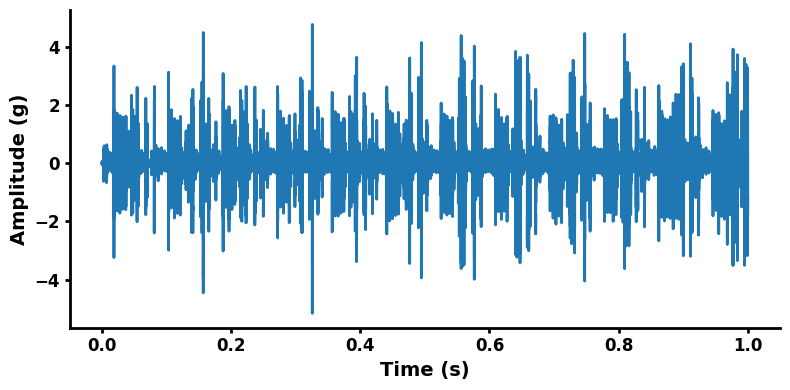

In [11]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

file_path = r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat"
mat = sio.loadmat(file_path)

signal = mat['signals'].squeeze()
fs = float(mat['fs'].squeeze())

t = np.arange(len(signal)) / fs

plt.figure(figsize=(8,4))
plt.plot(t, signal, linewidth=2)

plt.xlabel("Time (s)", fontsize=14, fontweight='bold')
plt.ylabel("Amplitude (g)", fontsize=14, fontweight='bold')

plt.grid(False)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', width=2, labelsize=12)

# ⭐ Bold tick numbers
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

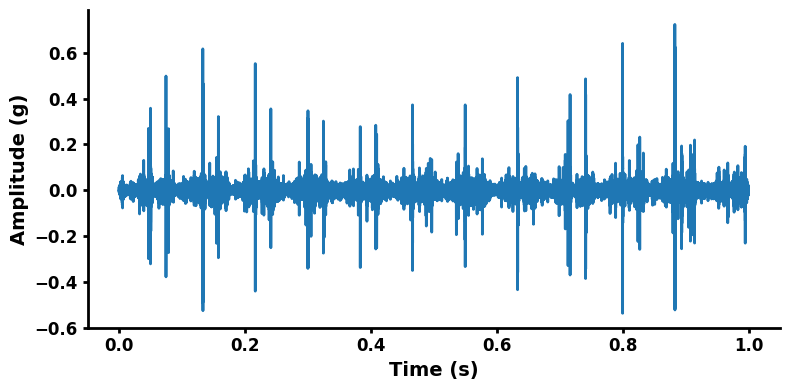

In [12]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

file_path = r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat"
mat = sio.loadmat(file_path)

signal = mat['signals'].squeeze()
fs = float(mat['fs'].squeeze())

t = np.arange(len(signal)) / fs

plt.figure(figsize=(8,4))
plt.plot(t, signal, linewidth=2)

plt.xlabel("Time (s)", fontsize=14, fontweight='bold')
plt.ylabel("Amplitude (g)", fontsize=14, fontweight='bold')

plt.grid(False)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', width=2, labelsize=12)

# ⭐ Bold tick numbers
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

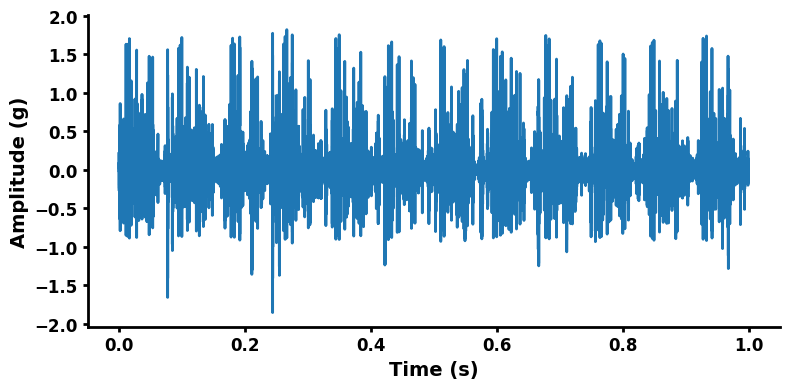

In [15]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

file_path = r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat"
mat = sio.loadmat(file_path)

signal = mat['signals'].squeeze()
fs = float(mat['fs'].squeeze())

t = np.arange(len(signal)) / fs

plt.figure(figsize=(8,4))
plt.plot(t, signal, linewidth=2)

plt.xlabel("Time (s)", fontsize=14, fontweight='bold')
plt.ylabel("Amplitude (g)", fontsize=14, fontweight='bold')

plt.grid(False)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', width=2, labelsize=12)

# ⭐ Bold tick numbers
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

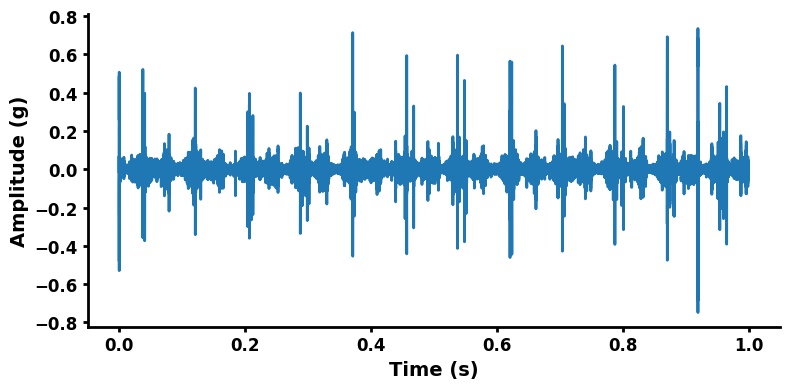

In [17]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

file_path = r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat"
mat = sio.loadmat(file_path)

signal = mat['signals'].squeeze()
fs = float(mat['fs'].squeeze())

t = np.arange(len(signal)) / fs

plt.figure(figsize=(8,4))
plt.plot(t, signal, linewidth=2)

plt.xlabel("Time (s)", fontsize=14, fontweight='bold')
plt.ylabel("Amplitude (g)", fontsize=14, fontweight='bold')

plt.grid(False)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', width=2, labelsize=12)

# ⭐ Bold tick numbers
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

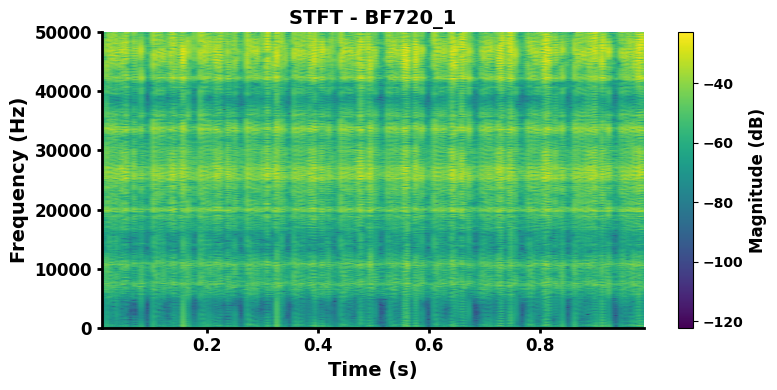

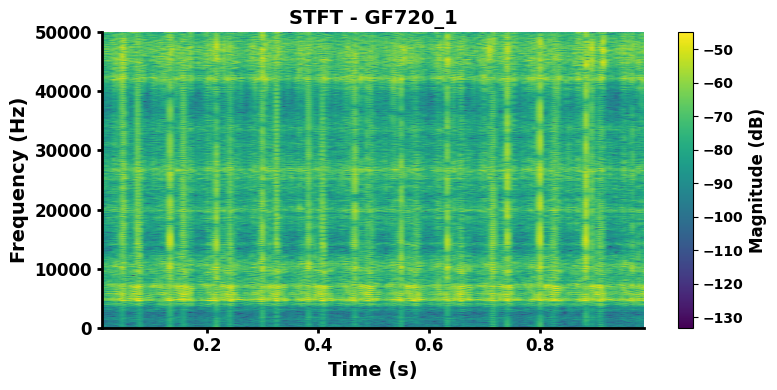

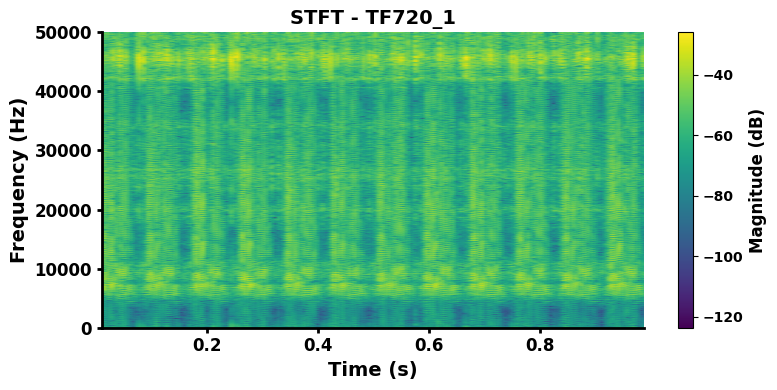

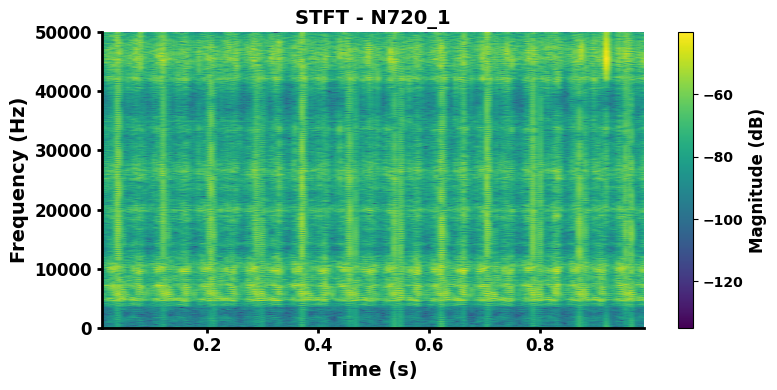

In [18]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

files = [
    (r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat", "BF720_1"),
    (r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat", "GF720_1"),
    (r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat", "TF720_1"),
    (r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat",  "N720_1"),
]

# --- STFT settings (tune these) ---
ds = 10                 # downsample factor for STFT speed (1 = no downsample)
nperseg = 2048          # window length
noverlap = 1536         # overlap
max_freq = None         # e.g. 200_000 to limit frequency axis (Hz), or None for full

def bold_axes(ax):
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', width=2, labelsize=12)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

for file_path, title in files:
    mat = sio.loadmat(file_path)
    x = mat['signals'].squeeze()
    fs = float(mat['fs'].squeeze())

    # Downsample for STFT plotting (optional but recommended)
    x_ds = x[::ds]
    fs_ds = fs / ds

    # STFT
    f, tt, Zxx = stft(
        x_ds,
        fs=fs_ds,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=False,
        boundary=None,
        padded=False
    )

    # Magnitude in dB
    mag = np.abs(Zxx)
    mag_db = 20 * np.log10(mag + 1e-12)

    # Optional frequency limit
    if max_freq is not None:
        idx = f <= max_freq
        f_plot = f[idx]
        mag_db_plot = mag_db[idx, :]
    else:
        f_plot = f
        mag_db_plot = mag_db

    # Plot STFT
    plt.figure(figsize=(8, 4))
    ax = plt.gca()

    im = ax.pcolormesh(tt, f_plot, mag_db_plot, shading='gouraud')
    cb = plt.colorbar(im)
    cb.set_label("Magnitude (dB)", fontsize=12, fontweight='bold')
    for lab in cb.ax.get_yticklabels():
        lab.set_fontweight('bold')

    ax.set_xlabel("Time (s)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Frequency (Hz)", fontsize=14, fontweight='bold')
    ax.set_title(f"STFT - {title}", fontsize=14, fontweight='bold')

    ax.grid(False)
    bold_axes(ax)

    plt.tight_layout()
    plt.show()

In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  STFT Heatmap — AE Signals (720 dataset)                                     ║
# ║  Reads sampling rate from .mat file                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import stft
from scipy.io import loadmat


# ── CONFIG ────────────────────────────────────────────────────────────────────

SAVE_DIR   = r"F:\Faisal Work\MCT Work\Diagrams\stft"
RUN_NAME   = "MEGNet_720"
NPERSEG    = 1024
NOVERLAP   = 768
DPI        = 800
CMAP       = "inferno"

EXAMPLE_FILES = {
    "BF": r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat",
    "GF": r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat",
    "TF": r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat",
    "N":  r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat",
}

os.makedirs(SAVE_DIR, exist_ok=True)


# ── LOAD SIGNAL ───────────────────────────────────────────────────────────────

def load_signal_and_fs(mat_path):
    mat = loadmat(mat_path)

    sig = mat["signals"].squeeze().astype(np.float64)
    fs  = float(mat["fs"].squeeze())

    return sig, fs


# ── COMPUTE STFT ──────────────────────────────────────────────────────────────

def compute_stft(sig, fs, nperseg=NPERSEG, noverlap=NOVERLAP):
    f, t, Zxx = stft(sig, fs=fs, nperseg=nperseg,
                     noverlap=noverlap, window="hann")

    power = np.abs(Zxx) ** 2
    Zdb   = 10 * np.log10(power + 1e-12)
    return f, t, Zdb


# ── SINGLE HEATMAP ────────────────────────────────────────────────────────────

def plot_stft_single(sig, fs, label,
                     fmax_khz=500, tmax_ms=None):

    f, t, Zdb = compute_stft(sig, fs)

    f_mask = f <= fmax_khz * 1000
    if tmax_ms is not None:
        t_mask = t <= tmax_ms / 1000
    else:
        t_mask = np.ones(len(t), dtype=bool)

    fig, ax = plt.subplots(figsize=(7,4.5))

    pcm = ax.pcolormesh(t[t_mask]*1000,
                        f[f_mask]/1000,
                        Zdb[np.ix_(f_mask, t_mask)],
                        shading="gouraud",
                        cmap=CMAP)

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label("Power (dB)", fontsize=12, fontweight="bold")

    ax.set_xlabel("Time (ms)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Frequency (kHz)", fontsize=14, fontweight="bold")
    ax.set_title(label, fontsize=14, fontweight="bold")

    ax.tick_params(axis='both', labelsize=12, width=2)
    for lbl in ax.get_xticklabels(): lbl.set_fontweight("bold")
    for lbl in ax.get_yticklabels(): lbl.set_fontweight("bold")

    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, f"{RUN_NAME}_{label}.png")
    plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    plt.savefig(save_path.replace(".png",".pdf"), bbox_inches="tight")
    plt.close()
    print("✓ saved:", save_path)


# ── GRID PLOT ─────────────────────────────────────────────────────────────────

def plot_stft_grid():

    signals = {}
    fs_list = {}

    for cls, path in EXAMPLE_FILES.items():
        sig, fs = load_signal_and_fs(path)
        signals[cls] = sig
        fs_list[cls] = fs

    fig, axes = plt.subplots(2,2, figsize=(12,7))
    axes = axes.ravel()

    pcm_last = None

    for i, (cls, sig) in enumerate(signals.items()):
        f, t, Z = compute_stft(sig, fs_list[cls])

        pcm = axes[i].pcolormesh(t*1000, f/1000, Z,
                                 shading="gouraud", cmap=CMAP)
        pcm_last = pcm

        axes[i].set_title(cls, fontweight="bold", fontsize=14)
        axes[i].set_xlabel("Time (ms)", fontweight="bold")
        axes[i].set_ylabel("Frequency (kHz)", fontweight="bold")

        axes[i].tick_params(labelsize=10)
        for lbl in axes[i].get_xticklabels(): lbl.set_fontweight("bold")
        for lbl in axes[i].get_yticklabels(): lbl.set_fontweight("bold")

    fig.colorbar(pcm_last, ax=axes, label="Power (dB)")

    save_path = os.path.join(SAVE_DIR, f"{RUN_NAME}_grid.png")
    plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    plt.close()
    print("✓ grid saved:", save_path)


# ── RUN ───────────────────────────────────────────────────────────────────────

plot_stft_grid()

✓ grid saved: F:\Faisal Work\MCT Work\Diagrams\stft\MEGNet_720_grid.png


In [21]:
# ── RUN: plot each class separately ───────────────────────────────────────────

for cls, path in EXAMPLE_FILES.items():
    sig, fs = load_signal_and_fs(path)

    plot_stft_single(
        sig,
        fs,
        label=cls,
        fmax_khz=500,     # change if needed
        tmax_ms=None      # or e.g. 10 for burst zoom
    )

✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\MEGNet_720_BF.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\MEGNet_720_GF.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\MEGNet_720_TF.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\MEGNet_720_N.png


In [22]:
duration_s = len(signal) / fs
print("fs (Hz):", fs)
print("N samples:", len(signal))
print("Duration (s):", duration_s)

fs (Hz): 1000000.0
N samples: 1000000
Duration (s): 1.0


In [23]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Time-domain + STFT (paper-ready) — 720 AE                                   ║
# ║  • Saves separate figures (PNG + PDF) for each class                         ║
# ║  • No titles, no grid, bold axes + bold tick values                          ║
# ║  • STFT is normalized: peak = 0 dB  (recommended for papers)                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import stft

# ── SAVE DIRS ────────────────────────────────────────────────────────────────
SAVE_DIR_SIG  = r"F:\Faisal Work\MCT Work\Diagrams\mct signal"
SAVE_DIR_STFT = r"F:\Faisal Work\MCT Work\Diagrams\stft"
os.makedirs(SAVE_DIR_SIG, exist_ok=True)
os.makedirs(SAVE_DIR_STFT, exist_ok=True)

# ── FILES ────────────────────────────────────────────────────────────────────
FILES = {
    "BF": r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat",
    "GF": r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat",
    "TF": r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat",
    "N":  r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat",
}

# ── PLOT/STFT CONFIG ─────────────────────────────────────────────────────────
DPI = 800
FIGSIZE_SIG  = (8, 4)
FIGSIZE_STFT = (8, 5)

# STFT params (good starting point for 1 MHz AE)
NPERSEG  = 2048
NOVERLAP = 1536

# Display limits for STFT
FMAX_KHZ = 500        # up to Nyquist for 1 MHz
TMAX_MS  = 1000       # full 1 second (1000 ms)
CMAP     = "inferno"

# Units: If you're not 100% sure it's "g", change to "a.u."
AMP_LABEL = "Amplitude (g)"


# ── HELPERS ──────────────────────────────────────────────────────────────────
def load_signal_and_fs(mat_path):
    mat = loadmat(mat_path)
    sig = mat["signals"].squeeze().astype(np.float64)
    fs  = float(mat["fs"].squeeze())
    return sig, fs

def style_axes_bold(ax, spine_w=2.5, tick_w=2.5, tick_size=14):
    ax.grid(False)
    ax.spines["bottom"].set_linewidth(spine_w)
    ax.spines["left"].set_linewidth(spine_w)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", width=tick_w, labelsize=tick_size, length=6)
    for lab in ax.get_xticklabels():
        lab.set_fontweight("bold")
    for lab in ax.get_yticklabels():
        lab.set_fontweight("bold")

def save_png_pdf(fig, save_path_no_ext):
    png_path = save_path_no_ext + ".png"
    pdf_path = save_path_no_ext + ".pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)
    print("✓ saved:", png_path)
    print("✓ saved:", pdf_path)

def compute_stft_db(sig, fs, nperseg=NPERSEG, noverlap=NOVERLAP):
    # boundary=None, padded=False keeps time axis aligned (no padding artifacts)
    f, t, Zxx = stft(
        sig, fs=fs, window="hann",
        nperseg=nperseg, noverlap=noverlap,
        return_onesided=True, boundary=None, padded=False
    )
    power = np.abs(Zxx) ** 2
    Zdb = 10 * np.log10(power + 1e-12)

    # Normalize so peak is 0 dB (paper-friendly + comparable across samples)
    Zdb -= Zdb.max()
    return f, t, Zdb


# ── PLOT FUNCTIONS ───────────────────────────────────────────────────────────
def plot_time_signal(sig, fs, label):
    t = np.arange(len(sig)) / fs

    fig, ax = plt.subplots(figsize=FIGSIZE_SIG)
    ax.plot(t, sig, linewidth=2)

    ax.set_xlabel("Time (s)", fontsize=16, fontweight="bold")
    ax.set_ylabel(AMP_LABEL, fontsize=16, fontweight="bold")
    style_axes_bold(ax)

    fig.tight_layout()
    save_png_pdf(fig, os.path.join(SAVE_DIR_SIG, f"{label}_signal"))

def plot_stft(sig, fs, label, fmax_khz=FMAX_KHZ, tmax_ms=TMAX_MS):
    f, t, Zdb = compute_stft_db(sig, fs)

    # Masks
    fmax_hz = min(fmax_khz * 1000, fs / 2)
    f_mask = f <= fmax_hz

    if tmax_ms is None:
        t_mask = np.ones_like(t, dtype=bool)
    else:
        t_mask = t <= (tmax_ms / 1000)

    f_plot = f[f_mask] / 1000        # kHz
    t_plot = t[t_mask] * 1000        # ms
    Z_plot = Zdb[np.ix_(f_mask, t_mask)]

    fig, ax = plt.subplots(figsize=FIGSIZE_STFT)
    pcm = ax.pcolormesh(
        t_plot, f_plot, Z_plot,
        shading="gouraud", cmap=CMAP, rasterized=True
    )

    ax.set_xlabel("Time (ms)", fontsize=16, fontweight="bold")
    ax.set_ylabel("Frequency (kHz)", fontsize=16, fontweight="bold")
    style_axes_bold(ax)

    # Colorbar (bold label + bold tick values)
    cbar = fig.colorbar(pcm, ax=ax, pad=0.02, fraction=0.05)
    cbar.set_label("Power (dB re max)", fontsize=16, fontweight="bold")
    cbar.ax.tick_params(labelsize=14, width=2.5, length=6)
    for lab in cbar.ax.get_yticklabels():
        lab.set_fontweight("bold")

    fig.tight_layout()
    save_png_pdf(fig, os.path.join(SAVE_DIR_STFT, f"{label}_stft"))


# ── RUN ALL (separate saves) ──────────────────────────────────────────────────
for label, path in FILES.items():
    sig, fs = load_signal_and_fs(path)

    # time-domain
    plot_time_signal(sig, fs, label)

    # stft
    plot_stft(sig, fs, label, fmax_khz=FMAX_KHZ, tmax_ms=TMAX_MS)

✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\BF_signal.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\BF_signal.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\BF_stft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\BF_stft.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\GF_signal.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\GF_signal.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\GF_stft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\GF_stft.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\TF_signal.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\TF_signal.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\TF_stft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\TF_stft.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\N_signal.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\mct signal\N_signal.pdf
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\N_stft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\stft\N_stft.

In [32]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Separate FFT plots — MSSP style (kHz axis)                                  ║
# ║  • Bold ticks + bold labels                                                  ║
# ║  • Frequency in kHz                                                          ║
# ║  • Saves PNG + PDF                                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ── SAVE DIR ──────────────────────────────────────────────────────────────────
SAVE_DIR = r"F:\Faisal Work\MCT Work\Diagrams\fft"
os.makedirs(SAVE_DIR, exist_ok=True)

FILES = {
    "BF": r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat",
    "GF": r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat",
    "TF": r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat",
    "N":  r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat",
}

DPI = 800
FIGSIZE = (5, 3)

# Optional zoom in kHz
FMAX_KHZ = None      # e.g. 200 for 0–200 kHz


# ── LOAD ──────────────────────────────────────────────────────────────────────
def load_signal(path):
    mat = loadmat(path)
    sig = mat["signals"].squeeze().astype(np.float64)
    fs  = float(mat["fs"].squeeze())
    return sig, fs


# ── FFT ───────────────────────────────────────────────────────────────────────
def amplitude_spectrum(sig, fs):
    N = len(sig)

    x = sig - np.mean(sig)

    w = np.hanning(N)
    xw = x * w
    cg = np.sum(w) / N

    X = np.fft.rfft(xw)
    f = np.fft.rfftfreq(N, d=1/fs)

    mag = (np.abs(X) / (N * cg)) * 2.0
    mag[0] *= 0.5

    return f/1000, mag   # ⭐ convert to kHz


# ── STYLE ─────────────────────────────────────────────────────────────────────
def style_axes(ax):
    ax.grid(False)

    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=11, width=2, length=4)

    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")


# ── RUN ───────────────────────────────────────────────────────────────────────
for label, path in FILES.items():

    sig, fs = load_signal(path)
    f_khz, mag = amplitude_spectrum(sig, fs)

    if FMAX_KHZ is not None:
        m = f_khz <= FMAX_KHZ
        f_khz = f_khz[m]
        mag = mag[m]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(f_khz, mag, linewidth=1.5)

    ax.set_xlabel("Frequency (kHz)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Magnitude (g)", fontsize=14, fontweight="bold")

    style_axes(ax)
    plt.tight_layout()

    png = os.path.join(SAVE_DIR, f"{label}_fft.png")
    pdf = os.path.join(SAVE_DIR, f"{label}_fft.pdf")

    fig.savefig(png, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)

    print("✓ saved:", png)

✓ saved: F:\Faisal Work\MCT Work\Diagrams\fft\BF_fft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\fft\GF_fft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\fft\TF_fft.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\fft\N_fft.png


In [33]:
#STE

In [34]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Short-Time Energy (STE) — AE signals (paper-ready)                          ║
# ║  • Computes STE with sliding window                                          ║
# ║  • Bold axes + bold tick values, no grid, no title                           ║
# ║  • Saves separate PNG + PDF for BF/GF/TF/N                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ── SAVE DIR ──────────────────────────────────────────────────────────────────
SAVE_DIR = r"F:\Faisal Work\MCT Work\Diagrams\ste"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── FILES ─────────────────────────────────────────────────────────────────────
FILES = {
    "BF": r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat",
    "GF": r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat",
    "TF": r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat",
    "N":  r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat",
}

# ── FIG SETTINGS ──────────────────────────────────────────────────────────────
DPI = 800
FIGSIZE = (8, 4)

# ── STE SETTINGS ──────────────────────────────────────────────────────────────
WIN_MS  = 1.0    # window length in ms (typical AE: 0.5–5 ms)
HOP_MS  = 0.2    # hop size in ms      (smaller = smoother curve)

# If you want normalized STE (0..1) for comparison, set True
NORMALIZE = True

# If you're not 100% sure signal unit is g/V, keep STE label as a.u.
STE_YLABEL = "Short-Time Energy (a.u.)"


# ── LOAD ──────────────────────────────────────────────────────────────────────
def load_signal(path):
    mat = loadmat(path)
    sig = mat["signals"].squeeze().astype(np.float64)
    fs  = float(mat["fs"].squeeze())
    return sig, fs


# ── STYLE ─────────────────────────────────────────────────────────────────────
def style_axes(ax):
    ax.grid(False)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.spines["left"].set_linewidth(2.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=12, width=2.5, length=6)
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")


# ── STE COMPUTE ───────────────────────────────────────────────────────────────
def short_time_energy(x, fs, win_ms=WIN_MS, hop_ms=HOP_MS):
    """
    STE[n] = sum_{k=0..L-1} x[n+k]^2  over a sliding window
    Returns:
        t_mid (s): time stamps at window centers
        ste    : short-time energy
    """
    x = np.asarray(x, dtype=np.float64)
    L = max(1, int(round(win_ms * 1e-3 * fs)))
    H = max(1, int(round(hop_ms * 1e-3 * fs)))

    # Efficient sliding energy using convolution
    x2 = x * x
    kernel = np.ones(L, dtype=np.float64)
    energy_full = np.convolve(x2, kernel, mode="valid")  # length N-L+1

    ste = energy_full[::H]
    # Time at window center
    centers = (np.arange(len(ste)) * H + (L / 2.0)) / fs
    return centers, ste


# ── PLOT ──────────────────────────────────────────────────────────────────────
for label, path in FILES.items():
    sig, fs = load_signal(path)

    t, ste = short_time_energy(sig, fs, WIN_MS, HOP_MS)

    if NORMALIZE:
        ste = ste / (np.max(ste) + 1e-12)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(t, ste, linewidth=2)

    ax.set_xlabel("Time (s)", fontsize=14, fontweight="bold")
    ax.set_ylabel(STE_YLABEL if not NORMALIZE else "Normalized STE (a.u.)",
                  fontsize=14, fontweight="bold")

    style_axes(ax)
    plt.tight_layout()

    out_base = os.path.join(SAVE_DIR, f"{label}_STE_{WIN_MS:g}ms_win_{HOP_MS:g}ms_hop")
    fig.savefig(out_base + ".png", dpi=DPI, bbox_inches="tight")
    fig.savefig(out_base + ".pdf", bbox_inches="tight")
    plt.close(fig)

    print("✓ saved:", out_base + ".png")

✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\BF_STE_1ms_win_0.2ms_hop.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\GF_STE_1ms_win_0.2ms_hop.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\TF_STE_1ms_win_0.2ms_hop.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\N_STE_1ms_win_0.2ms_hop.png


In [35]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Short-Time Energy (STE) — AE Signals                                      ║
# ║  Plots: STE curve · MAD threshold · detected burst regions                 ║
# ║  Saves to: F:\Faisal Work\MCT Work\Results\proposed                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from scipy.io import loadmat

# ── CONFIG ────────────────────────────────────────────────────────────────────

SAVE_DIR  = r"F:\Faisal Work\MCT Work\Results\proposed"
RUN_NAME  = "MEGNet_proposed"
FS        = 1_000_000     # 1 MHz
DPI       = 1000

# BIAES parameters (must match your MEGNet training code)
WIN       = 512           # STE window length (samples)
HOP       = 128           # STE hop size (samples)
K_MAD     = 4.0           # threshold multiplier
MIN_LEN   = 256           # minimum burst length (samples)
MERGE_GAP = 512           # merge gap (samples)

os.makedirs(SAVE_DIR, exist_ok=True)


# ── COMPUTE STE ───────────────────────────────────────────────────────────────

def compute_ste(sig, win=WIN, hop=HOP):
    """
    Compute Short-Time Energy using sliding window.
    STE(i) = (1/W) * sum( x[n]^2 ) for n in window i

    Returns:
        ste    — (N_frames,)  energy values
        frames — (N_frames,)  centre-sample index of each frame
    """
    n_frames = 1 + (len(sig) - win) // hop
    ste      = np.empty(n_frames, dtype=np.float64)
    frames   = np.empty(n_frames, dtype=np.float64)

    for i in range(n_frames):
        start      = i * hop
        chunk      = sig[start : start + win]
        ste[i]     = np.mean(chunk ** 2)
        frames[i]  = start + win // 2          # centre sample

    return ste, frames


# ── COMPUTE MAD THRESHOLD ────────────────────────────────────────────────────

def mad_threshold(ste, k=K_MAD):
    """
    Returns:
        tau     — scalar threshold value
        median  — median of STE
        mad     — MAD of STE
    """
    med = np.median(ste)
    mad = np.median(np.abs(ste - med))
    tau = med + k * mad
    return tau, med, mad


# ── DETECT BURST REGIONS ─────────────────────────────────────────────────────

def detect_bursts(sig, win=WIN, hop=HOP, k=K_MAD,
                  min_len=MIN_LEN, merge_gap=MERGE_GAP):
    """
    Returns list of (start_sample, end_sample) tuples.
    Mirrors BIAES logic from MEGNet training code.
    """
    ste, frames = compute_ste(sig, win, hop)
    tau, _, _   = mad_threshold(ste, k)

    above  = ste > tau
    bursts = []
    in_b   = False
    s_idx  = 0

    for i, flag in enumerate(above):
        if flag and not in_b:
            in_b  = True
            s_idx = i
        elif not flag and in_b:
            in_b = False
            bursts.append((int(frames[s_idx]), int(frames[i - 1])))

    if in_b:
        bursts.append((int(frames[s_idx]), int(frames[-1])))

    # Merge close bursts
    merged = []
    for b in bursts:
        if merged and (b[0] - merged[-1][1]) < merge_gap:
            merged[-1] = (merged[-1][0], b[1])
        else:
            merged.append(list(b))

    # Remove short bursts
    merged = [(s, e) for s, e in merged if (e - s) >= min_len]

    return merged


# ── PLOT 1: STE + threshold + raw signal (stacked) ───────────────────────────

def plot_ste_single(sig, label, fs=FS, win=WIN, hop=HOP, k=K_MAD,
                    tmax_ms=None, save_path=None):
    """
    2-panel figure:
      Top    — Raw AE signal with burst regions shaded
      Bottom — STE curve with MAD threshold line and burst shading
    """
    ste, frames   = compute_ste(sig, win, hop)
    tau, med, mad = mad_threshold(ste, k)
    bursts        = detect_bursts(sig, win, hop, k)

    time_sig = np.arange(len(sig)) / fs * 1000          # ms
    time_ste = frames / fs * 1000                        # ms

    # Optional time crop
    if tmax_ms is not None:
        sig_mask = time_sig <= tmax_ms
        ste_mask = time_ste <= tmax_ms
        time_sig = time_sig[sig_mask];  sig_plot = sig[sig_mask]
        time_ste = time_ste[ste_mask];  ste_plot = ste[ste_mask]
    else:
        sig_plot = sig;  ste_plot = ste

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 6), sharex=True,
        gridspec_kw={"height_ratios": [1.6, 1], "hspace": 0.06}
    )

    # ── Panel 1: Raw signal ──
    ax1.plot(time_sig, sig_plot, color="#1a5fa8", linewidth=0.6,
             alpha=0.85, zorder=2, label="AE Signal")

    for s, e in bursts:
        ts = s / fs * 1000;  te = e / fs * 1000
        if tmax_ms and ts > tmax_ms:
            break
        te = min(te, tmax_ms) if tmax_ms else te
        ax1.axvspan(ts, te, color="#c0392b", alpha=0.18, zorder=1)

    ax1.set_ylabel("Amplitude", fontsize=13, fontweight="bold")
    ax1.set_title(f"Raw AE Signal — {label}", fontsize=13, fontweight="bold")
    ax1.tick_params(axis="y", labelsize=11)
    for lb in ax1.get_yticklabels(): lb.set_fontweight("bold")
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))

    # ── Panel 2: STE ──
    ax2.plot(time_ste, ste_plot, color="#0a7a6a", linewidth=1.4,
             zorder=3, label="STE")
    ax2.fill_between(time_ste, ste_plot, alpha=0.18, color="#0a7a6a")

    # Threshold line
    ax2.axhline(tau, color="#c0392b", linewidth=1.8, linestyle="--",
                zorder=4, label=f"τ = median + {k}·MAD  ({tau:.4e})")

    # Median line
    ax2.axhline(med, color="#888", linewidth=1.2, linestyle=":",
                zorder=3, label=f"Median  ({med:.4e})")

    # Shade bursts on STE panel too
    for s, e in bursts:
        ts = s / fs * 1000;  te = e / fs * 1000
        if tmax_ms and ts > tmax_ms:
            break
        te = min(te, tmax_ms) if tmax_ms else te
        ax2.axvspan(ts, te, color="#c0392b", alpha=0.18, zorder=1)

    ax2.set_xlabel("Time (ms)", fontsize=13, fontweight="bold")
    ax2.set_ylabel("STE", fontsize=13, fontweight="bold")
    ax2.legend(loc="upper right", fontsize=10,
               prop={"weight": "bold"}, framealpha=0.88)

    for lb in ax2.get_xticklabels() + ax2.get_yticklabels():
        lb.set_fontweight("bold"); lb.set_fontsize(11)
    ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax2.tick_params(which="minor", length=3, color="gray")

    # Burst count annotation
    ax1.text(0.01, 0.97,
             f"Detected bursts: {len(bursts)}",
             transform=ax1.transAxes,
             fontsize=10, fontweight="bold", color="#c0392b",
             va="top", ha="left",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c0392b", alpha=0.85))

    # Legend patch for burst shading
    burst_patch = mpatches.Patch(color="#c0392b", alpha=0.25, label="Detected burst")
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles + [burst_patch],
               fontsize=10, prop={"weight": "bold"},
               loc="upper right", framealpha=0.88)

    plt.tight_layout()

    if save_path is None:
        save_path = os.path.join(SAVE_DIR, f"{RUN_NAME}_STE_{label}.png")

    plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    plt.savefig(save_path.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    print(f"  ✓ STE saved → {save_path}  |  bursts detected: {len(bursts)}")
    plt.close()


# ── PLOT 2: All 4 classes in 2×2 grid ────────────────────────────────────────

def plot_ste_grid(signals_dict, fs=FS, win=WIN, hop=HOP, k=K_MAD,
                  tmax_ms=None):
    """
    2×2 grid of STE curves — one per class, shared x-axis scale.
    """
    labels  = list(signals_dict.keys())
    signals = list(signals_dict.values())

    title_colors = {
        "BF": "#c0392b", "GF": "#1a5fa8",
        "N":  "#0a7a6a", "TF": "#e67e22",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=False)
    axes = axes.ravel()

    for i, (ax, lbl, sig) in enumerate(zip(axes, labels, signals)):
        ste, frames   = compute_ste(sig, win, hop)
        tau, med, _   = mad_threshold(ste, k)
        bursts        = detect_bursts(sig, win, hop, k)
        time_ste      = frames / fs * 1000

        if tmax_ms is not None:
            mask     = time_ste <= tmax_ms
            time_ste = time_ste[mask]
            ste      = ste[mask]

        col = title_colors.get(lbl, "#333")

        ax.plot(time_ste, ste, color=col, linewidth=1.2, zorder=3)
        ax.fill_between(time_ste, ste, alpha=0.2, color=col)

        # Threshold
        ax.axhline(tau, color="#c0392b", linewidth=1.6, linestyle="--",
                   label=f"τ = med+{k}·MAD", zorder=4)
        ax.axhline(med, color="#888", linewidth=1.1, linestyle=":",
                   label="Median", zorder=3)

        # Shade bursts
        for s, e in bursts:
            ts = s / fs * 1000;  te = e / fs * 1000
            if tmax_ms and ts > tmax_ms:
                break
            te = min(te, tmax_ms) if tmax_ms else te
            ax.axvspan(ts, te, color="#c0392b", alpha=0.14, zorder=1)

        ax.set_title(f"{lbl}  —  {len(bursts)} bursts detected",
                     fontsize=12, fontweight="bold", color=col)

        if i in (0, 2): ax.set_ylabel("STE", fontsize=11, fontweight="bold")
        if i in (2, 3): ax.set_xlabel("Time (ms)", fontsize=11, fontweight="bold")

        ax.legend(fontsize=8, prop={"weight": "bold"}, loc="upper right")
        for lb in ax.get_xticklabels() + ax.get_yticklabels():
            lb.set_fontweight("bold"); lb.set_fontsize(9)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
        ax.tick_params(which="minor", length=2.5, color="gray")

    fig.suptitle(
        f"Short-Time Energy (STE) — All Classes\n"
        f"Window={win} smp · Hop={hop} smp · k={k} · fs={FS//1000} kHz",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()

    sp = os.path.join(SAVE_DIR, f"{RUN_NAME}_STE_all_classes.png")
    plt.savefig(sp, dpi=DPI, bbox_inches="tight")
    plt.savefig(sp.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    print(f"  ✓ STE grid saved → {sp}")
    plt.close()


# ── PLOT 3: STE only (no raw signal panel) ───────────────────────────────────

def plot_ste_only(sig, label, fs=FS, win=WIN, hop=HOP, k=K_MAD,
                  tmax_ms=None, save_path=None):
    """
    Single-panel STE plot — clean version for paper figures.
    """
    ste, frames   = compute_ste(sig, win, hop)
    tau, med, _   = mad_threshold(ste, k)
    bursts        = detect_bursts(sig, win, hop, k)
    time_ste      = frames / fs * 1000

    if tmax_ms is not None:
        mask     = time_ste <= tmax_ms
        time_ste = time_ste[mask]
        ste      = ste[mask]

    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(time_ste, ste, color="#0a7a6a", linewidth=1.6,
            zorder=3, label="STE")
    ax.fill_between(time_ste, ste, alpha=0.2, color="#0a7a6a")

    ax.axhline(tau, color="#c0392b", linewidth=2, linestyle="--",
               label=f"Adaptive threshold τ = median + {k}·MAD", zorder=4)
    ax.axhline(med, color="#888", linewidth=1.3, linestyle=":",
               label=f"Median of STE", zorder=3)

    # Shade bursts
    first_burst = True
    for s, e in bursts:
        ts = s / fs * 1000;  te = e / fs * 1000
        if tmax_ms and ts > tmax_ms:
            break
        te  = min(te, tmax_ms) if tmax_ms else te
        lbl_burst = "Detected burst event" if first_burst else "_nolegend_"
        ax.axvspan(ts, te, color="#c0392b", alpha=0.18,
                   label=lbl_burst, zorder=1)
        first_burst = False

    ax.set_xlabel("Time (ms)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Short-Time Energy (STE)", fontsize=14, fontweight="bold")
    ax.set_title(f"Short-Time Energy — {label}  |  {len(bursts)} bursts detected",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=11,
              prop={"weight": "bold"}, framealpha=0.9)

    for lb in ax.get_xticklabels() + ax.get_yticklabels():
        lb.set_fontweight("bold"); lb.set_fontsize(12)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.tick_params(which="minor", length=3, color="gray")
    ax.grid(alpha=0.2, linestyle="--")

    plt.tight_layout()

    if save_path is None:
        save_path = os.path.join(SAVE_DIR, f"{RUN_NAME}_STE_only_{label}.png")

    plt.savefig(save_path, dpi=DPI, bbox_inches="tight")
    plt.savefig(save_path.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    print(f"  ✓ STE (single) saved → {save_path}")
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# ✏️  USAGE
# ─────────────────────────────────────────────────────────────────────────────
#
# ── Load a signal ────────────────────────────────────────────────────────────
#
#   from scipy.io import loadmat
#   mat       = loadmat(r"F:\20240925\BF660_1\AE\234721_AE.mat")
#   sig_array = mat["signals"].squeeze().astype(np.float64)
#
# ── Option A: 2-panel (raw signal + STE) — best for showing BIAES working ───
#
#   plot_ste_single(sig_array, label="BF")
#   plot_ste_single(sig_array, label="BF", tmax_ms=50)   # zoom to first 50 ms
#
# ── Option B: STE only — clean single panel for paper ────────────────────────
#
#   plot_ste_only(sig_array, label="BF")
#   plot_ste_only(sig_array, label="BF", tmax_ms=50)
#
# ── Option C: All 4 classes in 2×2 grid ──────────────────────────────────────
#
#   import glob
#   signals = {}
#   for cls, folder in {
#       "BF": r"F:\20240925\BF660_1\AE",
#       "GF": r"F:\20240925\GF660_1\AE",
#       "N":  r"F:\20240925\N660_1\AE",
#       "TF": r"F:\20240925\TF660_1\AE",
#   }.items():
#       path = sorted(glob.glob(folder + r"\*.mat"))[0]
#       mat  = loadmat(path)
#       signals[cls] = mat["signals"].squeeze().astype(np.float64)
#
#   plot_ste_grid(signals)
#   plot_ste_grid(signals, tmax_ms=100)   # zoom to first 100 ms
#
# ─────────────────────────────────────────────────────────────────────────────

In [37]:
import glob
signals = {}
for cls, folder in {
    "BF": r"F:\20240925\BF660_1\AE",
    "GF": r"F:\20240925\GF660_1\AE",
    "N":  r"F:\20240925\N660_1\AE",
    "TF": r"F:\20240925\TF660_1\AE",
}.items():
    path = sorted(glob.glob(folder + r"\*.mat"))[0]
    mat  = loadmat(path)
    signals[cls] = mat["signals"].squeeze().astype(np.float64)

plot_ste_grid(signals)

  ✓ STE grid saved → F:\Faisal Work\MCT Work\Results\proposed\MEGNet_proposed_STE_all_classes.png


C:\Users\Muhammad Umar\AppData\Local\Temp\ipykernel_19840\1740935851.py:290: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [40]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Signal + Short-Time Energy (paper-style STE visualization)                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

SAVE_DIR = r"F:\Faisal Work\MCT Work\Diagrams\ste"
os.makedirs(SAVE_DIR, exist_ok=True)

FILE = r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat"

WIN_MS = 1.0
HOP_MS = 0.2

# ── LOAD ──────────────────────────────────────────────────────────────────────
mat = loadmat(FILE)
sig = mat["signals"].squeeze().astype(np.float64)
fs  = float(mat["fs"].squeeze())

t = np.arange(len(sig)) / fs


# ── STE ───────────────────────────────────────────────────────────────────────
L = int(WIN_MS * 1e-3 * fs)
H = int(HOP_MS * 1e-3 * fs)

x2 = sig**2
ste = np.convolve(x2, np.ones(L), mode="valid")[::H]
t_ste = (np.arange(len(ste))*H + L/2) / fs

ste = ste / np.max(ste)


# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(2,1, figsize=(8,5), sharex=True)

# Signal
ax[0].plot(t, sig, linewidth=1.2)
ax[0].set_ylabel("Amplitude", fontweight="bold")

# STE
ax[1].plot(t_ste, ste, color="darkred", linewidth=2)
ax[1].set_ylabel("Normalized STE", fontweight="bold")
ax[1].set_xlabel("Time (s)", fontweight="bold")

# Styling (similar to your example)
for a in ax:
    a.grid(True, alpha=0.3)
    a.tick_params(labelsize=11)
    for lbl in a.get_xticklabels(): lbl.set_fontweight("bold")
    for lbl in a.get_yticklabels(): lbl.set_fontweight("bold")

plt.tight_layout()

out = os.path.join(SAVE_DIR, "BF_signal_STE.png")
plt.savefig(out, dpi=800)
plt.savefig(out.replace(".png",".pdf"))
plt.close()

print("✓ saved:", out)

✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\BF_signal_STE.png


In [41]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Separate STE plots — MSSP style                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ── SAVE DIR ──────────────────────────────────────────────────────────────────
SAVE_DIR = r"F:\Faisal Work\MCT Work\Diagrams\ste"
os.makedirs(SAVE_DIR, exist_ok=True)

FILES = {
    "BF": r"F:\D4B2\720\BF720_1\AE\20241021_165006_AE.mat",
    "GF": r"F:\D4B2\720\GF720_1\AE\20241021_002408_AE.mat",
    "TF": r"F:\D4B2\720\TF720_1\AE\20241021_105941_AE.mat",
    "N":  r"F:\D4B2\720\N720_1\AE\20241020_235017_AE.mat",
}

DPI = 800
FIGSIZE = (8,4)

# AE-friendly STE settings
WIN_MS = 1.0
HOP_MS = 0.2


# ── LOAD ──────────────────────────────────────────────────────────────────────
def load_signal(path):
    mat = loadmat(path)
    sig = mat["signals"].squeeze().astype(np.float64)
    fs  = float(mat["fs"].squeeze())
    return sig, fs


# ── STE ───────────────────────────────────────────────────────────────────────
def compute_ste(sig, fs):

    L = int(WIN_MS * 1e-3 * fs)
    H = int(HOP_MS * 1e-3 * fs)

    x2 = sig**2
    ste = np.convolve(x2, np.ones(L), mode="valid")[::H]
    t = (np.arange(len(ste))*H + L/2) / fs

    ste = ste / (np.max(ste) + 1e-12)   # normalize
    return t, ste


# ── STYLE ─────────────────────────────────────────────────────────────────────
def style_axes(ax):
    ax.grid(False)

    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=12, width=2, length=5)

    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")


# ── RUN ───────────────────────────────────────────────────────────────────────
for label, path in FILES.items():

    sig, fs = load_signal(path)
    t, ste = compute_ste(sig, fs)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(t, ste, linewidth=2, color="darkred")

    ax.set_xlabel("Time (s)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Normalized STE", fontsize=14, fontweight="bold")

    style_axes(ax)
    plt.tight_layout()

    png = os.path.join(SAVE_DIR, f"{label}_STE.png")
    pdf = os.path.join(SAVE_DIR, f"{label}_STE.pdf")

    fig.savefig(png, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)

    print("✓ saved:", png)

✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\BF_STE.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\GF_STE.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\TF_STE.png
✓ saved: F:\Faisal Work\MCT Work\Diagrams\ste\N_STE.png
